# 7단계 · MA 정렬 + ADX 시장국면 통합 전략

## 왜 기관·퀀트는 MA 정렬 + ADX를 쓰는가?

| 지표 | 역할 | 단독 한계 |
|------|------|----------|
| **MA 정렬** (20/60/120) | 단기·중기·장기 추세 **방향** 확인 | 추세 강도를 모름 → 횡보에서도 신호 발생 |
| **ADX** | 추세 **강도** 수치화 (0~100) | 방향을 모름 → 상승/하락 구분 불가 |
| **MA + ADX 결합** | 방향 + 강도 동시 확인 | — |

```
MA20 > MA60 > MA120  AND  ADX > 25  →  강한 상승 추세  (풀 포지션)
MA20 > MA60 > MA120  AND  ADX ≤ 25  →  약한 상승 추세  (부분 포지션)
MA 혼재                               →  횡보/조정       (소폭 포지션)
MA20 < MA60 < MA120                  →  하락 추세       (현금 보유)
```

## 전략 매핑 — 모든 시장 국면을 커버

| 국면 | 적용 전략 | 포지션 | 논리 |
|------|----------|--------|------|
| **강한 상승** | 골든크로스 OR MACD 상향 | **100%** | 추세 이중 확인 → 풀 포지션 |
| **약한 상승** | RSI 반등 AND OBV 확인 | **70%** | 거래량 뒷받침 필요 |
| **횡보/조정** | 볼린저 밴드 평균 회귀 | **50%** | 방향 불확실 → 리스크 절반 |
| **하락 추세** | 미진입 | **0%** | 손실 방어 최우선 |

## 학습 목표
1. `ma_regime_strategy.py` 모듈로 국면 판별 + 전략 전환 캡슐화
2. 골든크로스·MACD·RSI·OBV·볼린저밴드 6개 전략을 국면별로 연결
3. `targetpercent` 포지션 크기 조절로 리스크 최적화
4. 단독 전략 vs 국면 스위처 성과 비교

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드: 삼성전자 (005930.KS) 2019~2024 ──────────────────────────────
TICKER = '005930.KS'
START  = '2019-01-01'
END    = '2024-12-31'

df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close'].squeeze()
high   = df['High'].squeeze()
low    = df['Low'].squeeze()
volume = df['Volume'].squeeze()

print(f'종목  : 삼성전자 ({TICKER})')
print(f'기간  : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')
print(f'시작가: {close.iloc[0]:,.0f}원  /  종가: {close.iloc[-1]:,.0f}원')

종목  : 삼성전자 (005930.KS)
기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일
시작가: 32,297원  /  종가: 51,969원


---
## 1단계 · MA 3중 구조 분석 (20 / 60 / 120)

### 정렬 패턴 해석표

| 패턴 | 의미 | 대응 |
|------|------|------|
| MA20 > MA60 > MA120 | 단·중·장기 모두 상승 → **완전 상승 정렬** | 추세 추종 전략 |
| MA20 < MA60 < MA120 | 단·중·장기 모두 하락 → **완전 하락 정렬** | 현금 보유 |
| MA20 ≈ MA60 교차 반복 | 방향성 없음 → **횡보** | 평균 회귀 전략 |
| MA20 < MA60 > MA120 | 중기 꺾임, 장기 유효 → **조정 구간** | 관망/부분 청산 |

> **MA60(분기선)이 핵심**: 실적 발표 주기(분기)와 일치해 기관 포지션 기준선으로 활용됩니다.

=== MA 정렬 상태 분포 ===
  상승 정렬 (Bull) :  578일 (39.2%)
  하락 정렬 (Bear) :  360일 (24.4%)
  혼재 (횡보/조정) :  537일 (36.4%)


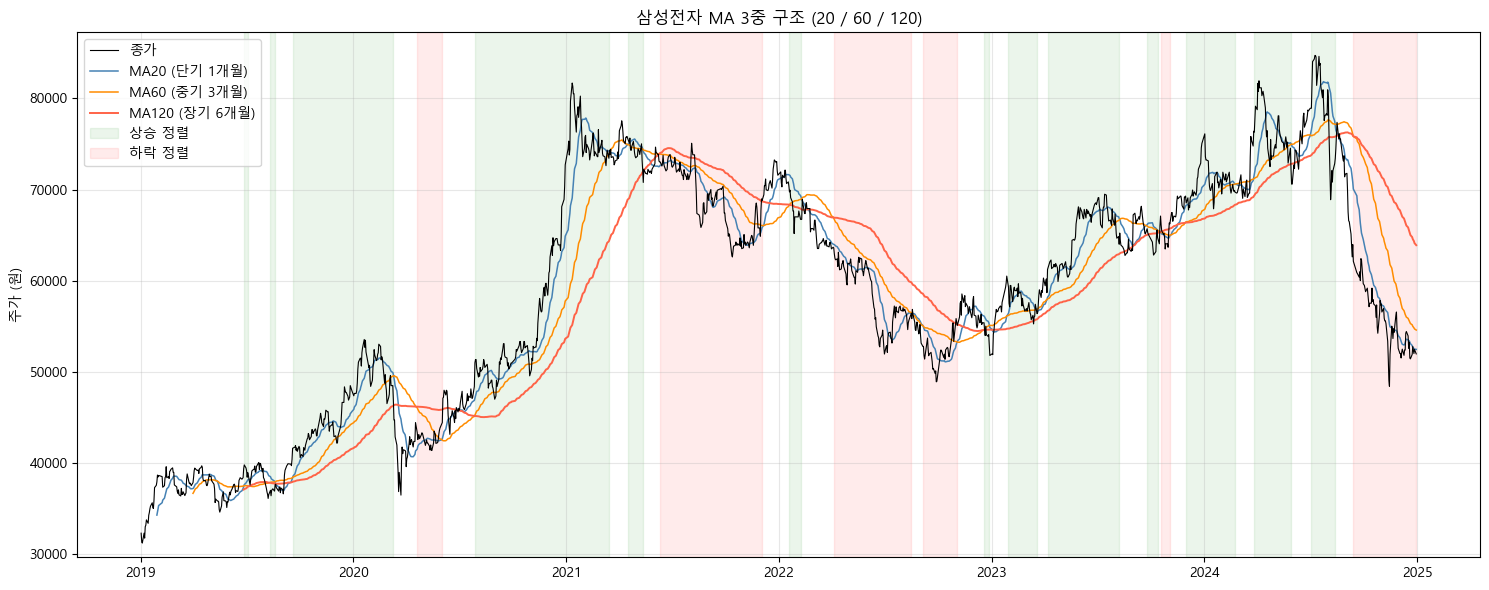

In [2]:
# ── MA 계산 ──────────────────────────────────────────────────────────────────
ma20  = close.rolling(20).mean()
ma60  = close.rolling(60).mean()
ma120 = close.rolling(120).mean()

bull_align = (ma20 > ma60) & (ma60 > ma120)
bear_align = (ma20 < ma60) & (ma60 < ma120)
mixed      = ~bull_align & ~bear_align

print('=== MA 정렬 상태 분포 ===')
total = len(close)
print(f'  상승 정렬 (Bull) : {bull_align.sum():4d}일 ({bull_align.mean():.1%})')
print(f'  하락 정렬 (Bear) : {bear_align.sum():4d}일 ({bear_align.mean():.1%})')
print(f'  혼재 (횡보/조정) : {mixed.sum():4d}일 ({mixed.mean():.1%})')

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(close, color='black',     linewidth=0.8, label='종가', zorder=5)
ax.plot(ma20,  color='steelblue', linewidth=1.1, label='MA20 (단기 1개월)')
ax.plot(ma60,  color='darkorange',linewidth=1.1, label='MA60 (중기 3개월)')
ax.plot(ma120, color='tomato',    linewidth=1.4, label='MA120 (장기 6개월)')

ymin, ymax = close.min() * 0.95, close.max() * 1.03
ax.fill_between(close.index, ymin, ymax, where=bull_align,
                color='green', alpha=0.08, label='상승 정렬')
ax.fill_between(close.index, ymin, ymax, where=bear_align,
                color='red',   alpha=0.08, label='하락 정렬')

ax.set_title('삼성전자 MA 3중 구조 (20 / 60 / 120)')
ax.set_ylabel('주가 (원)')
ax.set_ylim(ymin, ymax)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2단계 · ADX 추세 강도 분석

MA 정렬로 방향을 확인했다면, ADX로 **그 추세에 실제로 힘이 있는지** 검증합니다.

```
ADX < 20       → 횡보 (추세 없음)
ADX 20 ~ 25    → 과도기 (신호 신뢰도 낮음)
ADX 25 ~ 40    → 중간 추세 ← 기관 진입 구간
ADX > 40       → 강한 추세 (추격 매수 주의, 이미 많이 오름)
```

> **포인트**: MA 정렬 + ADX > 25를 **동시에** 만족할 때만 추세장으로 확정해야 휩쏘(가짜 신호)를 걸러낼 수 있습니다.

=== ADX 통계 ===
  평균 ADX         : 22.8
  ADX < 20 (횡보)   : 691일 (46.8%)
  ADX 20~25 (과도기): 275일
  ADX > 25 (추세)   : 496일 (33.6%)
  ADX > 40 (강추세) : 93일 (6.3%)


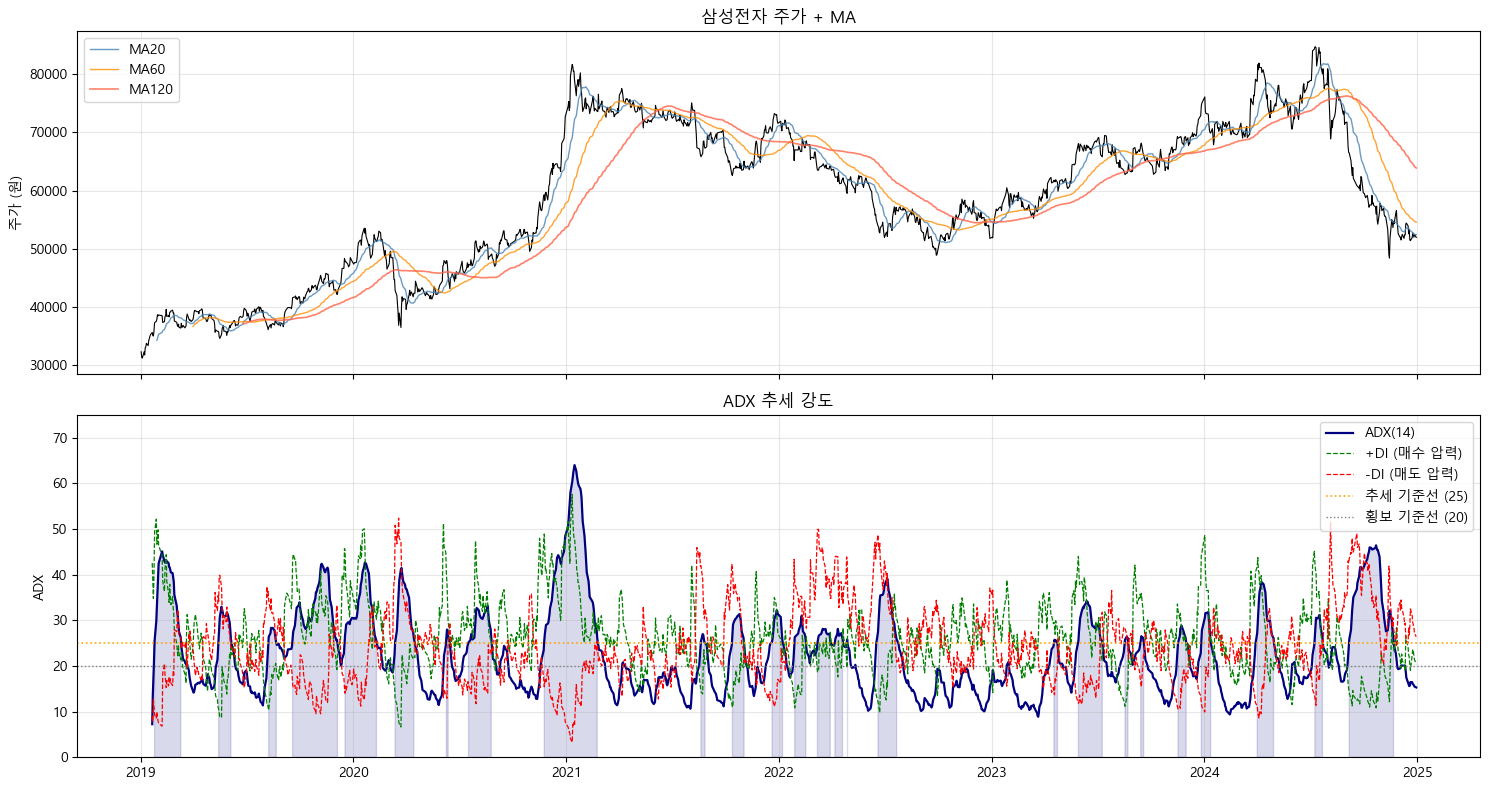

In [3]:
from vbt_backtest.strategies.adx_strategy import calc_adx

adx_df   = calc_adx(high, low, close, window=14)
adx      = adx_df['ADX']
plus_di  = adx_df['plus_di']
minus_di = adx_df['minus_di']

print('=== ADX 통계 ===')
print(f'  평균 ADX         : {adx.mean():.1f}')
print(f'  ADX < 20 (횡보)   : {(adx < 20).sum()}일 ({(adx < 20).mean():.1%})')
print(f'  ADX 20~25 (과도기): {((adx >= 20) & (adx < 25)).sum()}일')
print(f'  ADX > 25 (추세)   : {(adx >= 25).sum()}일 ({(adx >= 25).mean():.1%})')
print(f'  ADX > 40 (강추세) : {(adx > 40).sum()}일 ({(adx > 40).mean():.1%})')

# ── ADX 시각화 ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(close, color='black',      linewidth=0.8)
ax1.plot(ma20,  color='steelblue',  linewidth=1.0, alpha=0.8, label='MA20')
ax1.plot(ma60,  color='darkorange', linewidth=1.0, alpha=0.8, label='MA60')
ax1.plot(ma120, color='tomato',     linewidth=1.2, alpha=0.8, label='MA120')
ax1.set_title('삼성전자 주가 + MA')
ax1.set_ylabel('주가 (원)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(adx,      color='navy',   linewidth=1.6, label='ADX(14)')
ax2.plot(plus_di,  color='green',  linewidth=0.9, linestyle='--', label='+DI (매수 압력)')
ax2.plot(minus_di, color='red',    linewidth=0.9, linestyle='--', label='-DI (매도 압력)')
ax2.axhline(25, color='orange', linewidth=1.2, linestyle=':', label='추세 기준선 (25)')
ax2.axhline(20, color='gray',   linewidth=1.0, linestyle=':', label='횡보 기준선 (20)')
ax2.fill_between(adx.index, 0, adx, where=(adx >= 25), alpha=0.15, color='navy')
ax2.set_title('ADX 추세 강도')
ax2.set_ylabel('ADX')
ax2.set_ylim(0, 75)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3단계 · 시장 국면 자동 판별 (`ma_regime_strategy` 모듈 활용)

`ma_regime_strategy.py`의 `calc_regime()` 함수 한 줄로 5가지 국면을 분류합니다.  
모듈 내부에서 MA 3중 구조 + ADX를 계산하고 국면 라벨 Series를 반환합니다.

In [4]:
from vbt_backtest.strategies.ma_regime_strategy import (
    calc_regime, make_signals, run_backtest, REGIME_COLORS
)

# ── 국면 판별 ─────────────────────────────────────────────────────────────────
regime, masks, adx_info = calc_regime(close, high, low)

STRONG_BULL = masks['STRONG_BULL']
WEAK_BULL   = masks['WEAK_BULL']
RANGING     = masks['RANGING']
WEAK_BEAR   = masks['WEAK_BEAR']
STRONG_BEAR = masks['STRONG_BEAR']

print('=== 시장 국면 분포 (삼성전자 2019~2024) ===')
counts = regime.value_counts()
order = ['강한 상승', '약한 상승', '횡보/조정', '약한 하락', '강한 하락']
for name in order:
    cnt = counts.get(name, 0)
    print(f'  {name:8s}: {cnt:4d}일 ({cnt/len(regime):.1%})')

=== 시장 국면 분포 (삼성전자 2019~2024) ===
  강한 상승   :  255일 (17.3%)
  약한 상승   :  323일 (21.9%)
  횡보/조정   :  537일 (36.4%)
  약한 하락   :  259일 (17.6%)
  강한 하락   :  101일 (6.8%)


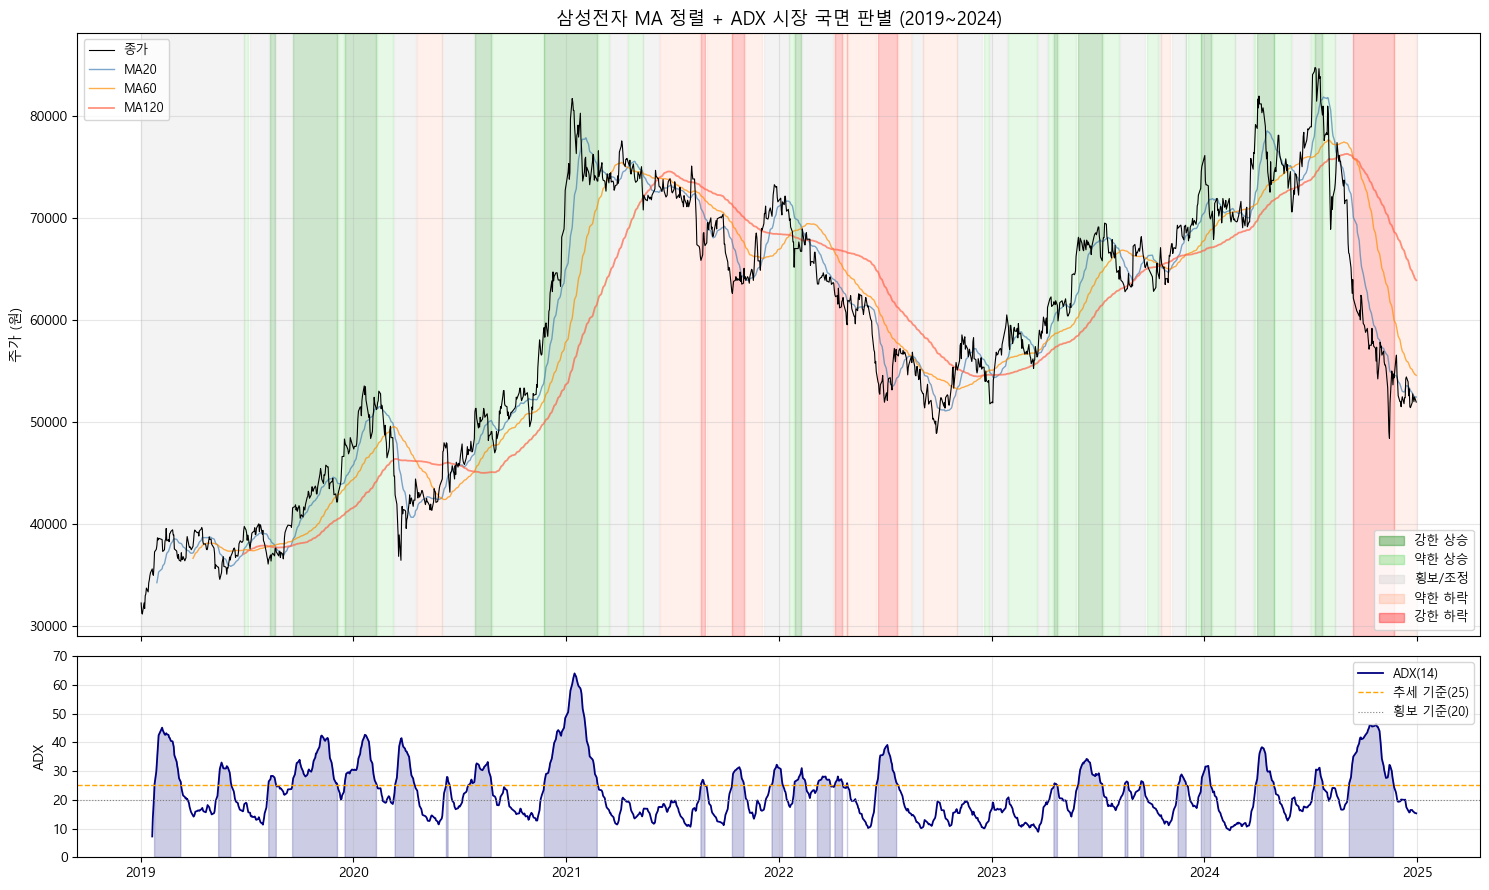

In [5]:
# ── 국면별 가격 차트 시각화 ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ymin, ymax = close.min() * 0.93, close.max() * 1.04
patches = []
for name, (color, alpha) in REGIME_COLORS.items():
    mask = regime == name
    ax1.fill_between(close.index, ymin, ymax, where=mask, color=color, alpha=alpha)
    patches.append(mpatches.Patch(color=color, alpha=alpha + 0.15, label=name))

ax1.plot(close,         color='black',      linewidth=0.8, zorder=5, label='종가')
ax1.plot(masks['ma_s'], color='steelblue',  linewidth=1.0, alpha=0.7, label='MA20')
ax1.plot(masks['ma_m'], color='darkorange', linewidth=1.0, alpha=0.7, label='MA60')
ax1.plot(masks['ma_l'], color='tomato',     linewidth=1.3, alpha=0.7, label='MA120')

ax1.set_title('삼성전자 MA 정렬 + ADX 시장 국면 판별 (2019~2024)', fontsize=13)
ax1.set_ylabel('주가 (원)')
ax1.set_ylim(ymin, ymax)
line_leg = ax1.legend(loc='upper left', fontsize=9)
ax1.add_artist(line_leg)
ax1.legend(handles=patches, loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: ADX 패널
adx_series = adx_info['ADX']
ax2.plot(adx_series, color='navy', linewidth=1.3, label='ADX(14)')
ax2.axhline(25, color='orange', linewidth=1.0, linestyle='--', label='추세 기준(25)')
ax2.axhline(20, color='gray',   linewidth=0.8, linestyle=':', label='횡보 기준(20)')
ax2.fill_between(adx_series.index, 0, adx_series,
                 where=(adx_series >= 25), alpha=0.2, color='navy')
ax2.set_ylabel('ADX')
ax2.set_ylim(0, 70)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4단계 · 국면별 전략 신호 생성

### 전략 선택 논리

**STRONG_BULL — 골든크로스 OR MACD 상향 (이중 확인)**
- 골든크로스(MA20>MA60)는 추세 전환 신호이지만 **발생 빈도 낮음**
- MACD 상향 돌파를 추가해 **진입 기회 보완**
- 두 신호 중 하나라도 발생 AND STRONG_BULL 국면 → 진입

**WEAK_BULL — RSI 반등 AND OBV 상승 (이중 필터)**
- 조정 구간이므로 반등 타이밍이 중요
- RSI 과매도 탈출만으로는 부족 → **OBV(거래량) 매집 확인**
- 세력이 매집 중(OBV > OBV MA)일 때만 진입 → 거짓 신호 감소

**RANGING — 볼린저 밴드 (평균 회귀)**
- 박스권에서 하단 밴드 이탈 후 복귀 → 매수
- 단독으로 사용 시 강한 추세에서 역추세 진입 위험 있음
- RANGING 국면 필터로 **적합한 시장 환경에서만** 활성화

In [6]:
# ── 국면별 전략 신호 생성 ─────────────────────────────────────────────────────
entries, exits, size_series, detail = make_signals(close, high, low, volume)

strong_entries = detail['strong_entries']
weak_entries   = detail['weak_entries']
range_entries  = detail['range_entries']

print('=== 국면 필터 적용 후 매수 신호 수 ===')
print(f'  강한 상승 (골든크로스 + MACD): {strong_entries.sum():3d}회')
print(f'  약한 상승 (RSI + OBV 확인)  : {weak_entries.sum():3d}회')
print(f'  횡보/조정 (볼린저 밴드)      : {range_entries.sum():3d}회')
print(f'  ─────────────────────────────────')
print(f'  전체 매수 신호               : {entries.sum():3d}회')

print()
print('=== 포지션 크기 분포 ===')
print(f'  100% 진입 (강한 상승): {(size_series == 1.0).sum()}회')
print(f'   70% 진입 (약한 상승): {(size_series == 0.7).sum()}회')
print(f'   50% 진입 (횡보/조정): {(size_series == 0.5).sum()}회')
print(f'    0% 청산            : {(size_series == 0.0).sum()}회')

=== 국면 필터 적용 후 매수 신호 수 ===
  강한 상승 (골든크로스 + MACD):   6회
  약한 상승 (RSI + OBV 확인)  :  24회
  횡보/조정 (볼린저 밴드)      :  13회
  ─────────────────────────────────
  전체 매수 신호               :  43회

=== 포지션 크기 분포 ===
  100% 진입 (강한 상승): 5회
   70% 진입 (약한 상승): 24회
   50% 진입 (횡보/조정): 0회
    0% 청산            : 722회


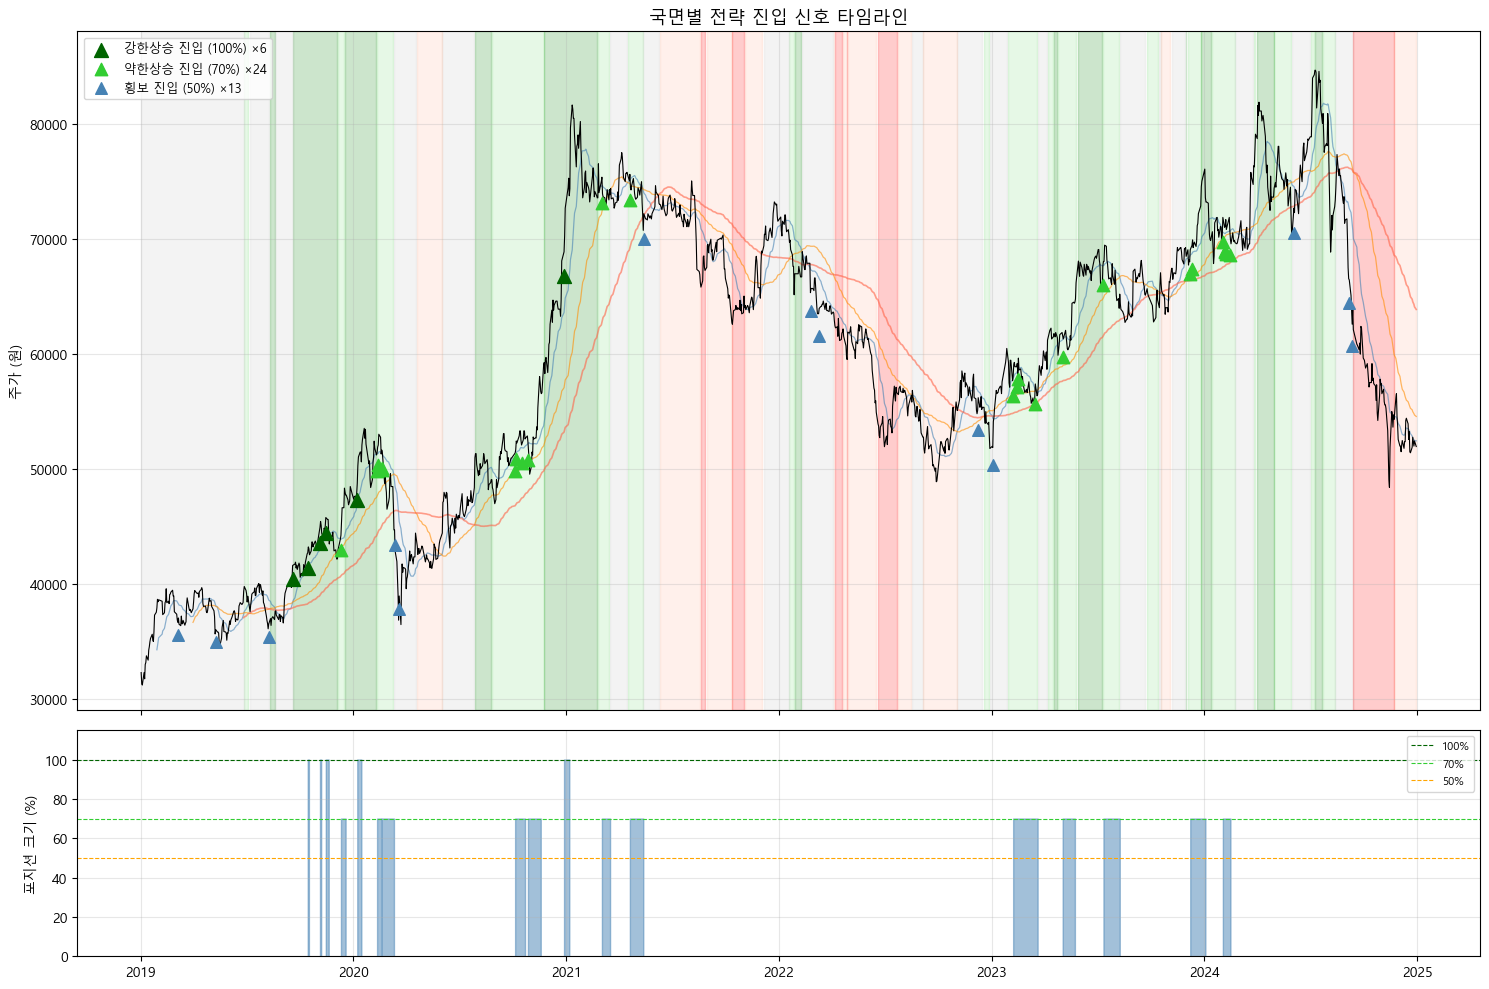

In [7]:
# ── 신호 타임라인 시각화 ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 상단: 주가 + 국면 배경 + 진입 신호 마커
ymin, ymax = close.min() * 0.93, close.max() * 1.04
for name, (color, alpha) in REGIME_COLORS.items():
    ax1.fill_between(close.index, ymin, ymax,
                     where=(regime == name), color=color, alpha=alpha)

ax1.plot(close,         color='black',      linewidth=0.8, zorder=5)
ax1.plot(masks['ma_s'], color='steelblue',  linewidth=0.9, alpha=0.6)
ax1.plot(masks['ma_m'], color='darkorange', linewidth=0.9, alpha=0.6)
ax1.plot(masks['ma_l'], color='tomato',     linewidth=1.2, alpha=0.6)

# 진입 신호 마커 (삼각형)
ax1.scatter(close.index[strong_entries], close[strong_entries] * 0.97,
            marker='^', color='darkgreen', s=100, zorder=10,
            label=f'강한상승 진입 (100%) ×{strong_entries.sum()}')
ax1.scatter(close.index[weak_entries], close[weak_entries] * 0.97,
            marker='^', color='limegreen', s=80, zorder=10,
            label=f'약한상승 진입 (70%) ×{weak_entries.sum()}')
ax1.scatter(close.index[range_entries], close[range_entries] * 0.97,
            marker='^', color='steelblue', s=70, zorder=10,
            label=f'횡보 진입 (50%) ×{range_entries.sum()}')

ax1.set_title('국면별 전략 진입 신호 타임라인', fontsize=13)
ax1.set_ylabel('주가 (원)')
ax1.set_ylim(ymin, ymax)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 포지션 크기
size_filled = size_series.fillna(method='ffill').fillna(0)
ax2.fill_between(close.index, 0, size_filled * 100,
                 color='steelblue', alpha=0.5, step='post')
ax2.axhline(100, color='darkgreen', linewidth=0.8, linestyle='--', label='100%')
ax2.axhline(70,  color='limegreen', linewidth=0.8, linestyle='--', label='70%')
ax2.axhline(50,  color='orange',    linewidth=0.8, linestyle='--', label='50%')
ax2.set_ylabel('포지션 크기 (%)')
ax2.set_ylim(0, 115)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5단계 · 전략 비교 백테스트

### 비교 대상

| 전략 | 설명 |
|------|------|
| Buy & Hold | 기준선 |
| 골든크로스 단독 | 국면 필터 없음 |
| MACD 단독 | 국면 필터 없음 |
| RSI 단독 | 국면 필터 없음 |
| 볼린저 밴드 단독 | 국면 필터 없음 |
| OBV 단독 | 국면 필터 없음 |
| **국면 스위처** | MA + ADX 국면 필터 + 6전략 조합 + 포지션 크기 조절 |

In [8]:
from vbt_backtest.strategies import (
    golden_cross, macd_strategy, rsi_strategy,
    bollinger_band, obv_strategy
)

FEES     = 0.0015   # 한국 주식 수수료 약 0.15%
SLIPPAGE = 0.001

def make_pf_signals(entries, exits):
    return vbt.Portfolio.from_signals(
        close, entries, exits,
        fees=FEES, slippage=SLIPPAGE, freq='D'
    )

# ── 개별 전략 (국면 필터 없음) ────────────────────────────────────────────────
gc_e,  gc_x  = golden_cross.make_signals(close)
macd_e, macd_x = macd_strategy.make_signals(close)
rsi_e, rsi_x  = rsi_strategy.make_signals(close)
bb_e,  bb_x  = bollinger_band.make_signals(close)
obv_e, obv_x  = obv_strategy.make_signals(close, volume)

# ── Buy & Hold ────────────────────────────────────────────────────────────────
bh_e = pd.Series(False, index=close.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close.index); bh_x.iloc[-1] = True

pf_bh   = make_pf_signals(bh_e, bh_x)
pf_gc   = make_pf_signals(gc_e, gc_x)
pf_macd = make_pf_signals(macd_e, macd_x)
pf_rsi  = make_pf_signals(rsi_e, rsi_x)
pf_bb   = make_pf_signals(bb_e, bb_x)
pf_obv  = make_pf_signals(obv_e, obv_x)

# ── 국면 스위처 (포지션 크기 조절 포함) ──────────────────────────────────────
pf_regime = vbt.Portfolio.from_orders(
    close,
    size=size_series,
    size_type='targetpercent',
    fees=FEES,
    slippage=SLIPPAGE,
    freq='D',
)

print('백테스트 완료')
print(f'  초기 자금: 10,000,000원 (기본값)')
print(f'  수수료: {FEES:.2%}  /  슬리피지: {SLIPPAGE:.2%}')

백테스트 완료
  초기 자금: 10,000,000원 (기본값)
  수수료: 0.15%  /  슬리피지: 0.10%


In [9]:
# ── 성과 비교 테이블 ──────────────────────────────────────────────────────────
strategies = {
    'Buy & Hold':       pf_bh,
    '골든크로스 단독':    pf_gc,
    'MACD 단독':         pf_macd,
    'RSI 단독':          pf_rsi,
    '볼린저밴드 단독':    pf_bb,
    'OBV 단독':          pf_obv,
    '★ 국면 스위처':     pf_regime,
}

rows = []
for name, pf in strategies.items():
    try:
        trades = pf.trades.count()
    except Exception:
        trades = '-'
    rows.append({
        '전략':       name,
        '총 수익률':  f"{pf.total_return():.2%}",
        '연평균(CAGR)': f"{pf.annualized_return():.2%}",
        '샤프비율':   f"{pf.sharpe_ratio():.2f}",
        '최대낙폭(MDD)': f"{pf.max_drawdown():.2%}",
        '거래횟수':   trades,
    })

df_result = pd.DataFrame(rows).set_index('전략')
print('=== 전략 성과 비교 (삼성전자 2019~2024) ===')
print(df_result.to_string())

=== 전략 성과 비교 (삼성전자 2019~2024) ===
              총 수익률 연평균(CAGR)   샤프비율 최대낙폭(MDD)  거래횟수
전략                                                  
Buy & Hold   60.11%    12.35%   0.53   -42.85%     1
골든크로스 단독      8.92%     2.14%   0.21   -44.42%    14
MACD 단독      16.68%     3.89%   0.28   -37.52%    56
RSI 단독      -12.62%    -3.28%  -0.09   -40.76%     5
볼린저밴드 단독     24.34%     5.54%   0.35   -37.43%    16
OBV 단독      -32.66%    -9.32%  -0.35   -50.25%   103
★ 국면 스위처     -0.45%    -0.11%   0.03   -14.29%    24


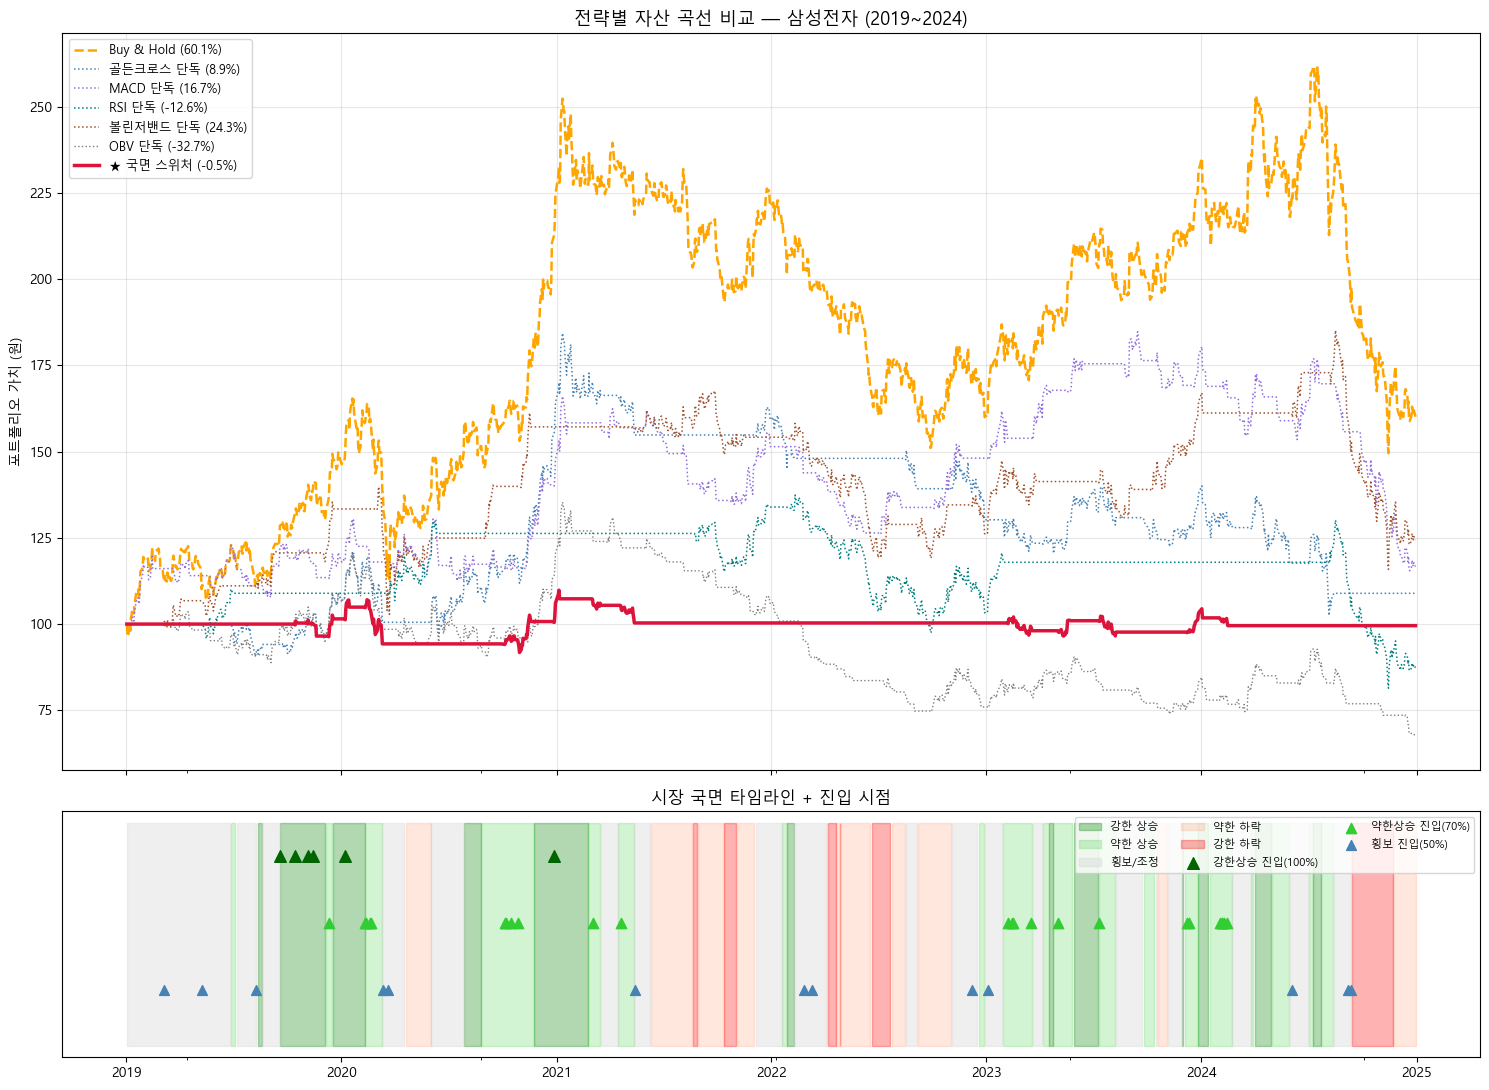

In [10]:
# ── 자산 곡선 비교 차트 ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

style_map = {
    'Buy & Hold':       ('orange',      '--', 1.8),
    '골든크로스 단독':    ('steelblue',  ':',  1.1),
    'MACD 단독':         ('mediumpurple',':',  1.1),
    'RSI 단독':          ('teal',       ':',  1.1),
    '볼린저밴드 단독':    ('sienna',     ':',  1.1),
    'OBV 단독':          ('gray',       ':',  1.0),
    '★ 국면 스위처':     ('crimson',    '-',  2.5),
}

for name, pf in strategies.items():
    color, ls, lw = style_map[name]
    ret = pf.total_return()
    pf.value().plot(ax=ax1, label=f'{name} ({ret:.1%})',
                    color=color, linestyle=ls, linewidth=lw)

ax1.set_title('전략별 자산 곡선 비교 — 삼성전자 (2019~2024)', fontsize=13)
ax1.set_ylabel('포트폴리오 가치 (원)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 국면 타임라인
for name, (color, alpha) in REGIME_COLORS.items():
    ax2.fill_between(close.index, 0, 1,
                     where=(regime == name), color=color, alpha=alpha + 0.1,
                     label=name)

ax2.scatter(close.index[strong_entries], [0.85] * strong_entries.sum(),
            marker='^', color='darkgreen', s=70, zorder=5, label='강한상승 진입(100%)')
ax2.scatter(close.index[weak_entries], [0.55] * weak_entries.sum(),
            marker='^', color='limegreen', s=55, zorder=5, label='약한상승 진입(70%)')
ax2.scatter(close.index[range_entries], [0.25] * range_entries.sum(),
            marker='^', color='steelblue', s=50, zorder=5, label='횡보 진입(50%)')

ax2.set_title('시장 국면 타임라인 + 진입 시점')
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=8, ncol=3)
ax2.grid(False)

plt.tight_layout()
plt.show()

---
## 6단계 · 국면별 수익률 심층 분석

각 국면에서 실제로 얼마나 수익이 났는지 분석합니다.  
이를 통해 전략이 어느 구간에서 효과적인지 파악하고 파라미터 개선 방향을 찾습니다.

=== 국면별 일간 수익률 통계 ===
국면               평균     표준편차     양봉%     거래일
------------------------------------------------
강한 상승        0.075%   1.638%   47.5%     255
약한 상승        0.058%   1.684%   48.0%     323
횡보/조정        0.114%   1.683%   50.9%     536
약한 하락       -0.092%   1.424%   41.3%     259
강한 하락       -0.072%   1.980%   41.6%     101


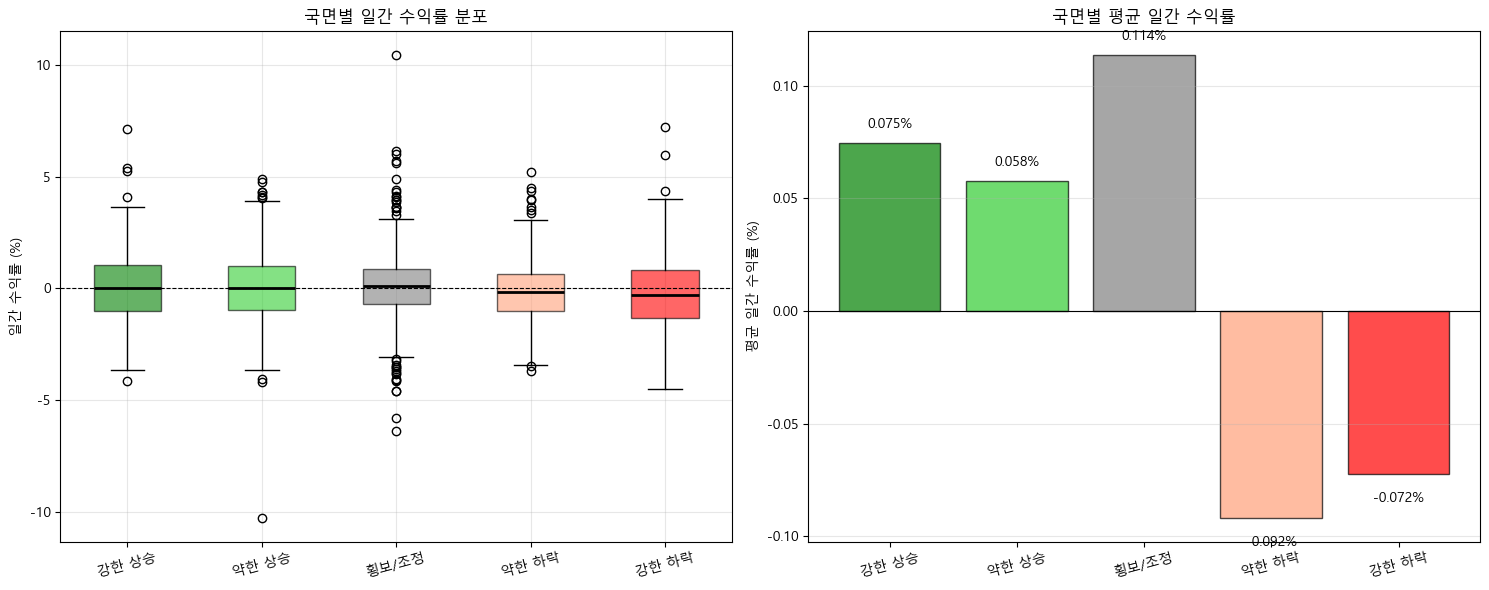

In [11]:
# ── 국면별 주가 수익률 분포 ───────────────────────────────────────────────────
daily_ret = close.pct_change()

regime_order = ['강한 상승', '약한 상승', '횡보/조정', '약한 하락', '강한 하락']
regime_colors_list = ['green', 'limegreen', 'gray', 'lightsalmon', 'red']

print('=== 국면별 일간 수익률 통계 ===')
print(f'{"국면":10s}  {"평균":>7s}  {"표준편차":>7s}  {"양봉%":>6s}  {"거래일":>6s}')
print('-' * 48)
for r in regime_order:
    mask = regime == r
    r_ret = daily_ret[mask].dropna()
    if len(r_ret) == 0:
        continue
    print(f'{r:10s}  {r_ret.mean():>7.3%}  {r_ret.std():>7.3%}  '
          f'{(r_ret > 0).mean():>6.1%}  {len(r_ret):>6d}')

# ── 국면별 수익률 박스플롯 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 박스플롯
data_by_regime = [daily_ret[regime == r].dropna() * 100 for r in regime_order]
bp = axes[0].boxplot(data_by_regime, patch_artist=True,
                     labels=regime_order, notch=False,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], regime_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('국면별 일간 수익률 분포')
axes[0].set_ylabel('일간 수익률 (%)')
axes[0].set_xticklabels(regime_order, rotation=15)
axes[0].grid(True, alpha=0.3)

# 평균 수익률 막대 그래프
means = [daily_ret[regime == r].dropna().mean() * 100 for r in regime_order]
bars = axes[1].bar(regime_order, means, color=regime_colors_list, alpha=0.7, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + (0.005 if val >= 0 else -0.008),
                 f'{val:.3f}%', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)
axes[1].set_title('국면별 평균 일간 수익률')
axes[1].set_ylabel('평균 일간 수익률 (%)')
axes[1].set_xticklabels(regime_order, rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

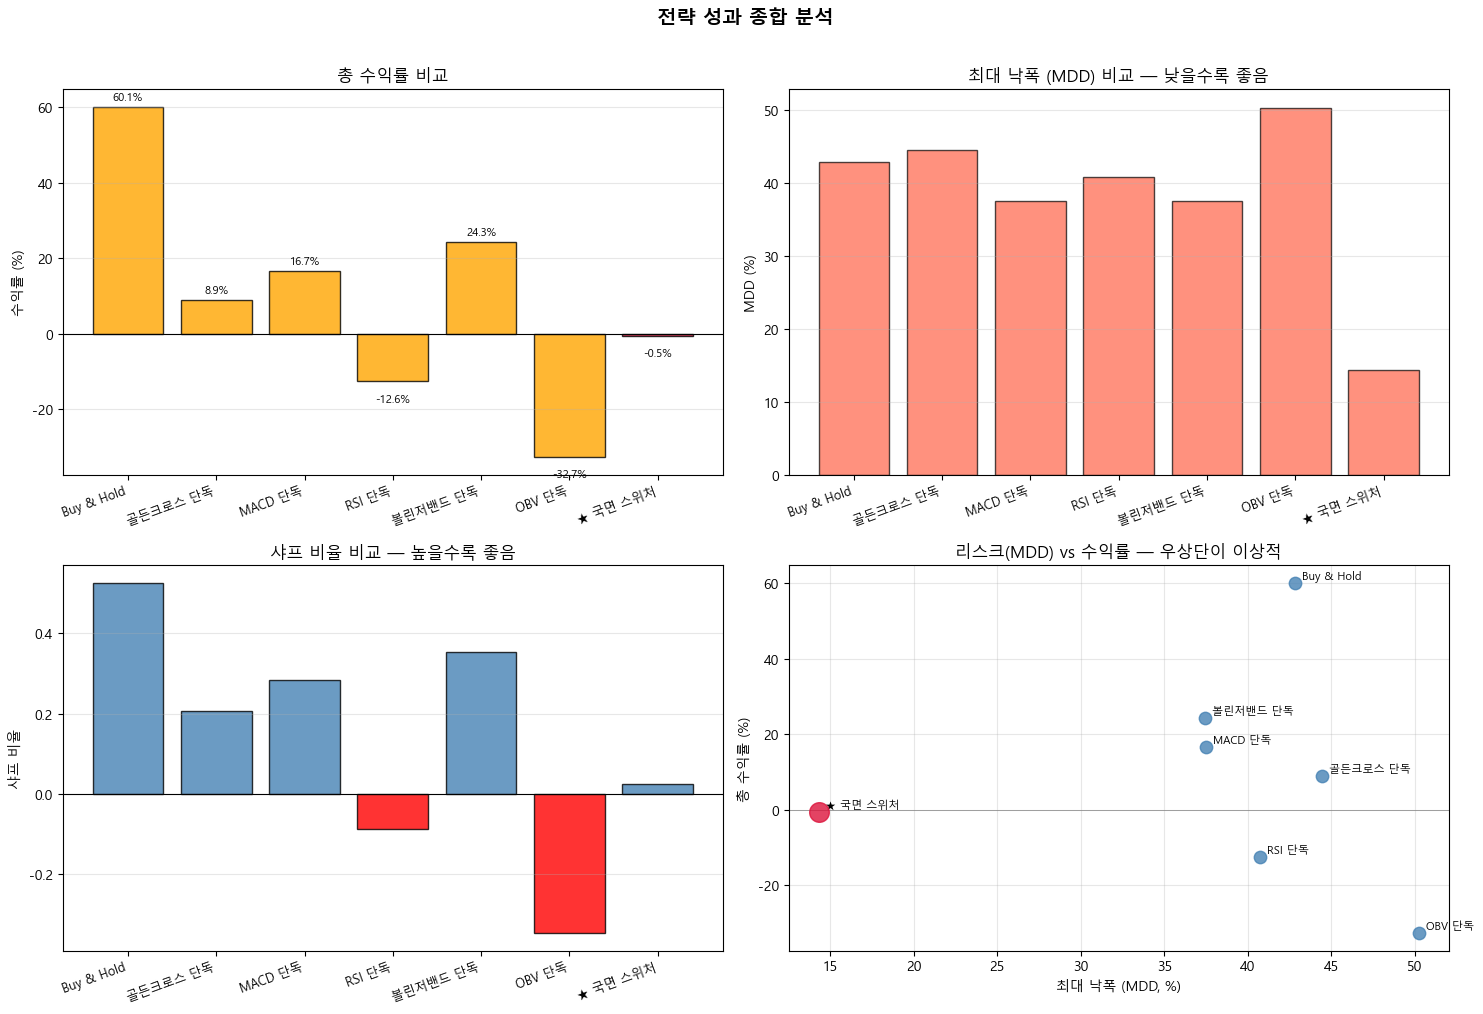

In [12]:
# ── 국면 스위처 드로다운 분석 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) 수익률 바 차트
names = list(strategies.keys())
returns = [pf.total_return() * 100 for pf in strategies.values()]
colors  = ['orange' if '★' not in n else 'crimson' for n in names]
bars = axes[0, 0].bar(range(len(names)), returns, color=colors, alpha=0.8, edgecolor='black')
axes[0, 0].set_xticks(range(len(names)))
axes[0, 0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0, 0].set_title('총 수익률 비교')
axes[0, 0].set_ylabel('수익률 (%)')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, returns):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    val + (1 if val >= 0 else -3),
                    f'{val:.1f}%', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

# 2) MDD 바 차트
mdds = [abs(pf.max_drawdown()) * 100 for pf in strategies.values()]
axes[0, 1].bar(range(len(names)), mdds, color='tomato', alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(names)))
axes[0, 1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0, 1].set_title('최대 낙폭 (MDD) 비교 — 낮을수록 좋음')
axes[0, 1].set_ylabel('MDD (%)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3) 샤프비율 바 차트
sharpes = [pf.sharpe_ratio() for pf in strategies.values()]
c3 = ['steelblue' if v >= 0 else 'red' for v in sharpes]
axes[1, 0].bar(range(len(names)), sharpes, color=c3, alpha=0.8, edgecolor='black')
axes[1, 0].set_xticks(range(len(names)))
axes[1, 0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1, 0].set_title('샤프 비율 비교 — 높을수록 좋음')
axes[1, 0].set_ylabel('샤프 비율')
axes[1, 0].axhline(0, color='black', linewidth=0.8)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4) 수익률/MDD 산점도 (리스크-수익 프론티어)
for name, pf in strategies.items():
    color = 'crimson' if '★' in name else 'steelblue'
    size  = 200 if '★' in name else 80
    axes[1, 1].scatter(abs(pf.max_drawdown()) * 100,
                       pf.total_return() * 100,
                       color=color, s=size, zorder=5, alpha=0.8)
    axes[1, 1].annotate(name,
                        (abs(pf.max_drawdown()) * 100, pf.total_return() * 100),
                        fontsize=8, xytext=(5, 3), textcoords='offset points')

axes[1, 1].set_xlabel('최대 낙폭 (MDD, %)')
axes[1, 1].set_ylabel('총 수익률 (%)')
axes[1, 1].set_title('리스크(MDD) vs 수익률 — 우상단이 이상적')
axes[1, 1].axhline(0, color='gray', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('전략 성과 종합 분석', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7단계 · 월별 수익률 히트맵 (국면 스위처)

월별 수익률을 연도×월 히트맵으로 표현하면 **어느 시기에 손실이 집중됐는지** 파악할 수 있습니다.

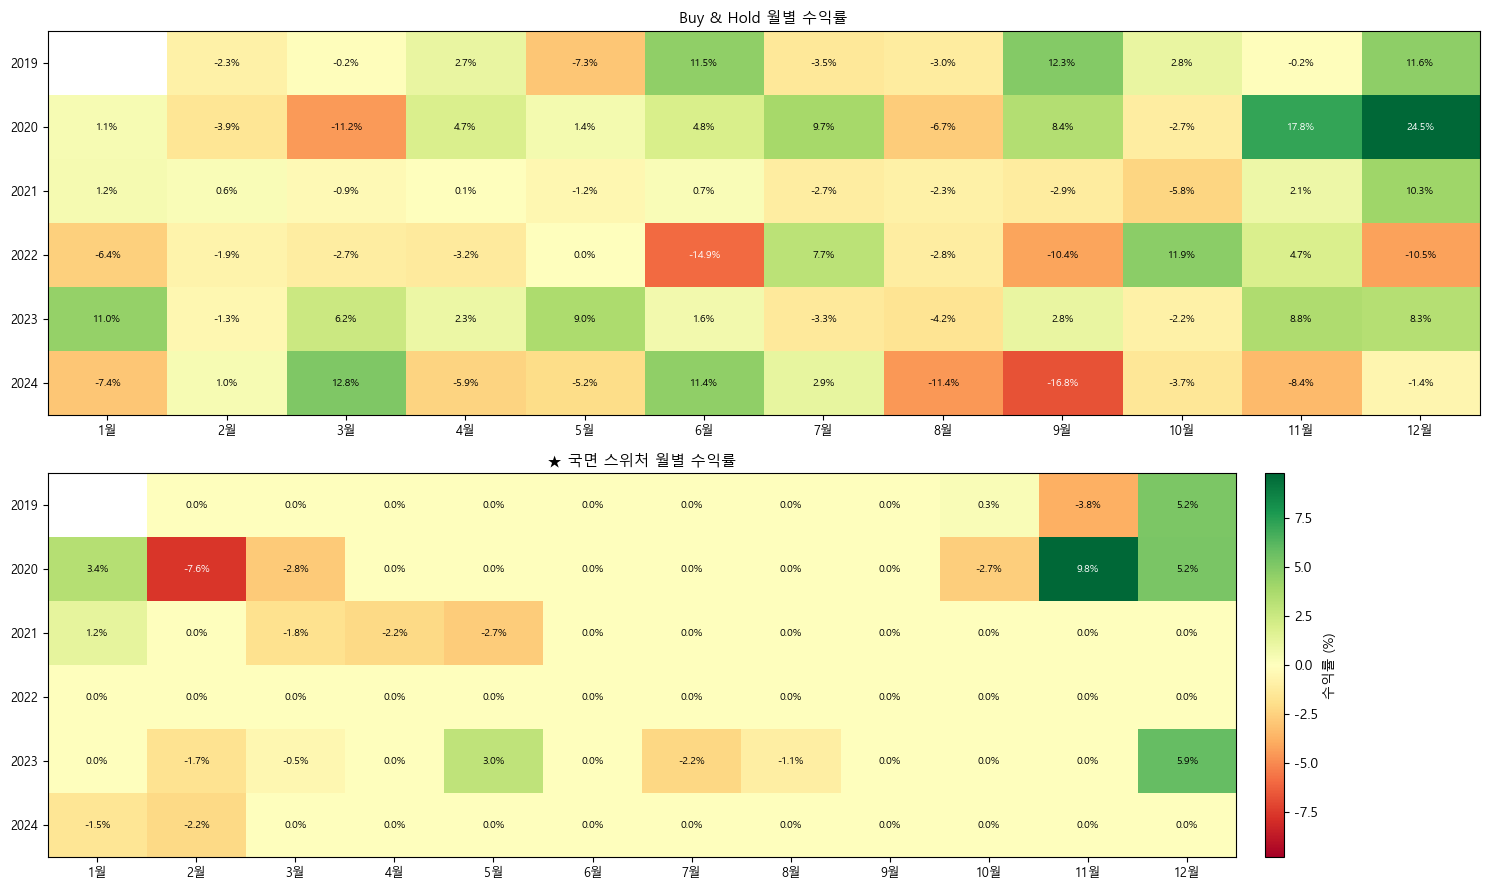

In [13]:
# ── 월별 수익률 히트맵 ────────────────────────────────────────────────────────
def monthly_heatmap(pf, title, ax):
    """포트폴리오 월별 수익률 히트맵 그리기"""
    val = pf.value()
    monthly = val.resample('M').last()
    mret = monthly.pct_change().dropna()

    pivot = pd.DataFrame({
        'year':  mret.index.year,
        'month': mret.index.month,
        'ret':   mret.values,
    }).pivot(index='year', columns='month', values='ret') * 100

    pivot.columns = ['1월','2월','3월','4월','5월','6월',
                     '7월','8월','9월','10월','11월','12월']

    import matplotlib.cm as cm
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 1)
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(12))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=11)

    for i in range(len(pivot.index)):
        for j in range(12):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                        fontsize=7.5, color='black' if abs(v) < vmax * 0.6 else 'white')

    return im

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

im1 = monthly_heatmap(pf_bh,     'Buy & Hold 월별 수익률',  axes[0])
im2 = monthly_heatmap(pf_regime, '★ 국면 스위처 월별 수익률', axes[1])

plt.colorbar(im2, ax=axes[1], label='수익률 (%)', pad=0.02)
plt.tight_layout()
plt.show()

---
## 8단계 · 파라미터 감도 분석

ADX 임계값(threshold)을 변화시키면 국면 분류가 달라지고 성과가 바뀝니다.  
어떤 ADX 기준이 가장 좋은 샤프비율을 내는지 빠르게 확인합니다.

=== ADX 임계값별 성과 (국면 스위처) ===
          총 수익률     연평균  샤프비율      MDD  거래횟수
ADX 임계값                                     
15        0.36%   0.09%  0.05  -13.22%    23
18       12.41%   2.94%  0.40  -12.03%    24
20        0.57%   0.14%  0.06  -14.04%    20
22        1.32%   0.33%  0.08  -17.02%    21
25       -0.45%  -0.11%  0.03  -14.29%    24
28       -1.03%  -0.26%  0.01  -14.72%    24
30        0.93%   0.23%  0.07  -14.29%    27
35       -2.71%  -0.68% -0.05  -14.29%    27


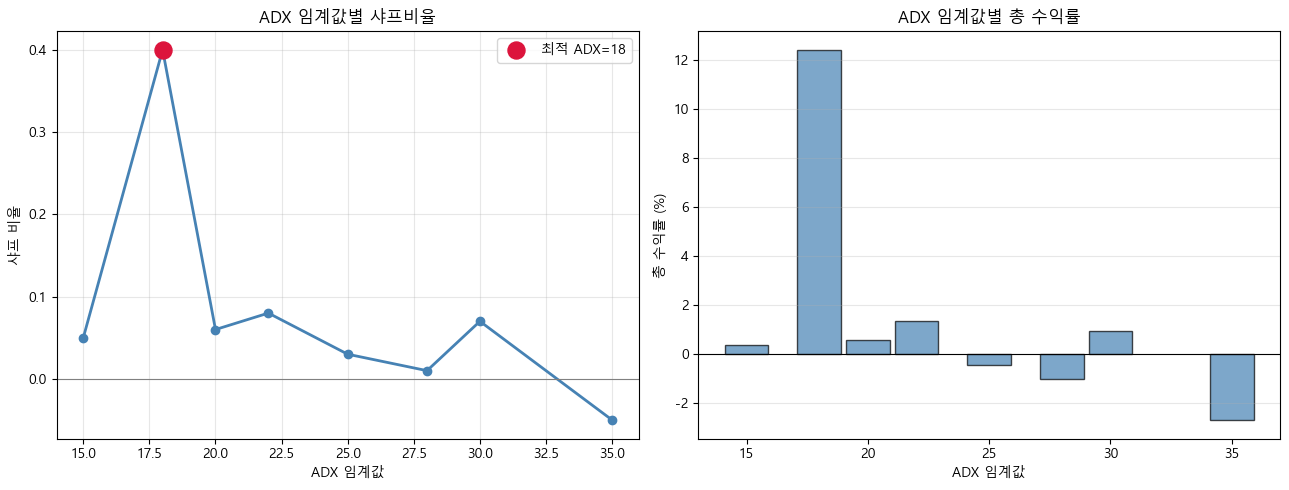


최적 ADX 임계값: 18 (샤프비율 0.40)


In [14]:
# ── ADX 임계값별 성과 스캔 ────────────────────────────────────────────────────
adx_thresholds = [15, 18, 20, 22, 25, 28, 30, 35]

scan_rows = []
for thresh in adx_thresholds:
    _, _, sz, _ = make_signals(close, high, low, volume, adx_threshold=thresh)
    pf_t = vbt.Portfolio.from_orders(
        close, size=sz, size_type='targetpercent',
        fees=FEES, slippage=SLIPPAGE, freq='D',
    )
    scan_rows.append({
        'ADX 임계값': thresh,
        '총 수익률':  f'{pf_t.total_return():.2%}',
        '연평균':     f'{pf_t.annualized_return():.2%}',
        '샤프비율':   round(pf_t.sharpe_ratio(), 2),
        'MDD':       f'{pf_t.max_drawdown():.2%}',
        '거래횟수':   pf_t.trades.count(),
    })

df_scan = pd.DataFrame(scan_rows).set_index('ADX 임계값')
print('=== ADX 임계값별 성과 (국면 스위처) ===')
print(df_scan.to_string())

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sharpes = df_scan['샤프비율'].values
ax1.plot(adx_thresholds, sharpes, 'o-', color='steelblue', linewidth=2)
ax1.axhline(0, color='gray', linewidth=0.8)
best_idx = int(np.argmax(sharpes))
ax1.scatter([adx_thresholds[best_idx]], [sharpes[best_idx]],
            color='crimson', s=150, zorder=5, label=f'최적 ADX={adx_thresholds[best_idx]}')
ax1.set_title('ADX 임계값별 샤프비율')
ax1.set_xlabel('ADX 임계값')
ax1.set_ylabel('샤프 비율')
ax1.legend()
ax1.grid(True, alpha=0.3)

rets = [float(df_scan.loc[t, '총 수익률'].rstrip('%')) for t in adx_thresholds]
ax2.bar(adx_thresholds, rets, color='steelblue', alpha=0.7, width=1.8, edgecolor='black')
ax2.set_title('ADX 임계값별 총 수익률')
ax2.set_xlabel('ADX 임계값')
ax2.set_ylabel('총 수익률 (%)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f'\n최적 ADX 임계값: {adx_thresholds[best_idx]} (샤프비율 {sharpes[best_idx]:.2f})')

---
## 정리

### 이 노트북에서 배운 것

| 개념 | 핵심 포인트 |
|------|------------|
| **MA 3중 정렬** | MA20 > MA60 > MA120 → 단·중·장기 모두 같은 방향 = 추세 신뢰도 최고 |
| **ADX 강도 필터** | MA 정렬이 되어도 ADX < 20이면 추세 없는 횡보 → 추세 전략 금지 |
| **국면별 전략 매핑** | 추세장 → 추세 추종(GC+MACD), 횡보 → 평균 회귀(BB), 조정 → 거래량 확인(RSI+OBV) |
| **포지션 크기 조절** | 확신도에 비례한 비중 → 불확실 구간 손실 억제 + 확실 구간 수익 극대화 |
| **파라미터 감도** | ADX 임계값이 국면 분류에 민감 → in/out-of-sample 분리 검증 필수 |

### 기관·퀀트가 MA 정렬 + ADX를 쓰는 실제 이유

```
1. 단순하다  — 복잡한 ML 없이 3~4개 지표로 모든 국면 대응
2. 해석 가능하다 — "왜 진입했는가"를 설명할 수 있음 (규제 대응)
3. 강건하다  — 종목/자산군이 달라도 동일 로직으로 적용 가능
4. 리스크가 명확하다 — 하락 추세에서 완전 이탈 (MDD 제어)
```

### 한계 및 다음 단계
- **후행성**: MA120 기반이라 국면 변화 감지에 수주 지연 (해결: 더 짧은 MA 또는 EMA)
- **단일 종목**: 삼성전자 한 종목으로만 테스트 → 다중 종목 포트폴리오로 확장 필요
- **과최적화**: ADX 감도 스캔 결과를 그대로 사용하면 과적합 → `08_성과분석_최적화.ipynb`에서 in/out-of-sample 검증

```python
# 최적 파라미터로 국면 스위처 재실행 예시
pf_best = run_backtest(close, high, low, volume,
                       adx_threshold=<최적값>,
                       fees=0.0015)
```